In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [3]:
df = pd.read_csv('../../datasets/Algerian_forest_fires_dataset_cleaned.csv')
df.head()       

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [4]:
df.drop(['day', 'month', 'year'], axis=1, inplace=True)

In [5]:
df['Classes'] = np.where(df['Classes'].str.lower().str.strip() == 'not fire', 0, 1)

In [6]:
df['Classes'].value_counts()


Classes
1    137
0    106
Name: count, dtype: int64

In [7]:
X = df.drop('FWI', axis=1)
y = df['FWI']


In [8]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [9]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((194, 11), (49, 11), (194,), (49,))

In [10]:
X_train.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
Temperature,1.000000,-0.653725,-0.308149,-0.313112,0.690285,0.468911,0.372163,0.613138,0.446280,0.539642,0.258344
RH,-0.653725,1.000000,0.211645,0.239441,-0.649239,-0.401836,-0.220945,-0.714640,-0.346511,-0.454926,-0.408441
Ws,-0.308149,0.211645,1.000000,0.235922,-0.176596,0.004712,0.092866,-0.002300,0.037465,-0.075322,-0.202357
Rain,-0.313112,0.239441,0.235922,1.000000,-0.547864,-0.288538,-0.301110,-0.349903,-0.299179,-0.378585,-0.057382
FFMC,0.690285,-0.649239,-0.176596,-0.547864,1.000000,0.611978,0.519513,0.751819,0.598248,0.786012,0.254770
DMC,0.468911,-0.401836,0.004712,-0.288538,0.611978,1.000000,0.876122,0.679049,0.983891,0.606775,0.188980
DC,0.372163,-0.220945,0.092866,-0.301110,0.519513,0.876122,1.000000,0.512934,0.946181,0.538893,-0.083038
ISI,0.613138,-0.714640,-0.002300,-0.349903,0.751819,0.679049,0.512934,1.000000,0.637669,0.740072,0.291889
BUI,0.446280,-0.346511,0.037465,-0.299179,0.598248,0.983891,0.946181,0.637669,1.000000,0.602102,0.090326
Classes,0.539642,-0.454926,-0.075322,-0.378585,0.786012,0.606775,0.538893,0.740072,0.602102,1.000000,0.196276


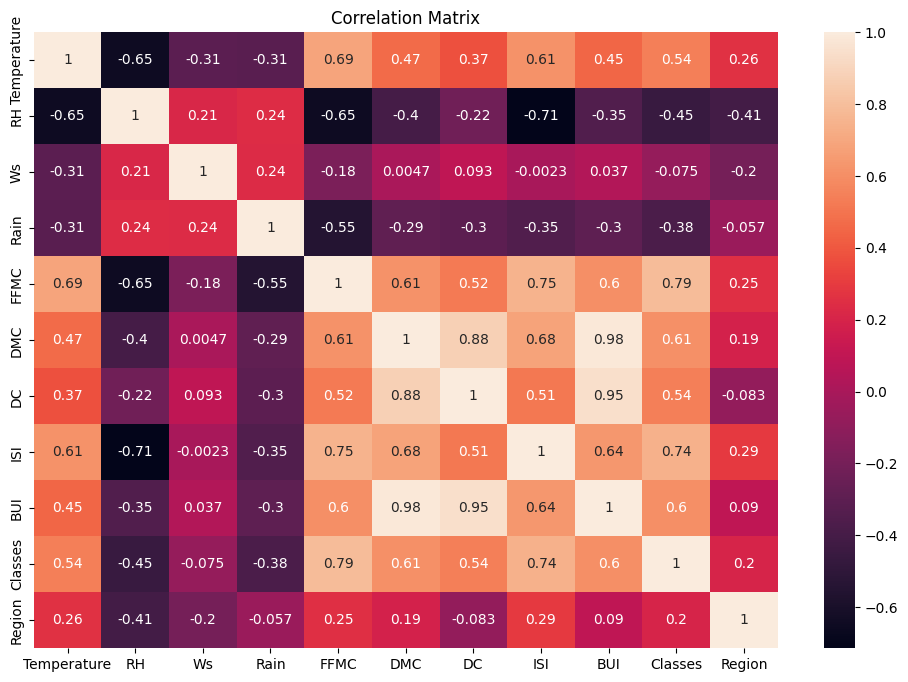

In [11]:
plt.figure(figsize=(12, 8))
plt.title('Correlation Matrix')
sns.heatmap(X_train.corr(), annot=True)

plt.show()

In [12]:
def correlation(dataset,thresold):
    col_corr = set()
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > thresold:
                colname = corr_matrix.columns[i]
                col_corr.add(colname)
    return col_corr

In [13]:
correlation(X_train, 0.85)

{'BUI', 'DC'}

In [14]:
X_train.drop(['BUI', 'DC'], axis=1, inplace=True)
X_test.drop(['BUI', 'DC'], axis=1, inplace=True)

In [15]:
X_train.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,ISI,Classes,Region
115,29,65,19,0.6,68.3,5.5,1.5,0,0
207,33,37,16,0.0,92.2,61.3,13.1,1,1
158,38,43,13,0.5,85.0,13.0,4.1,1,1
132,31,42,21,0.0,90.6,18.2,13.4,1,1
84,34,64,14,0.0,88.9,40.5,9.0,1,0


In [16]:
X_test.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,ISI,Classes,Region
24,31,64,15,0.0,86.7,14.2,5.7,1,0
6,33,54,13,0.0,88.2,9.9,6.4,1,0
152,28,58,18,2.2,63.7,3.2,1.2,0,1
232,34,58,13,0.2,79.5,18.7,2.1,0,1
238,30,65,14,0.0,85.4,16.0,4.5,1,1


In [17]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


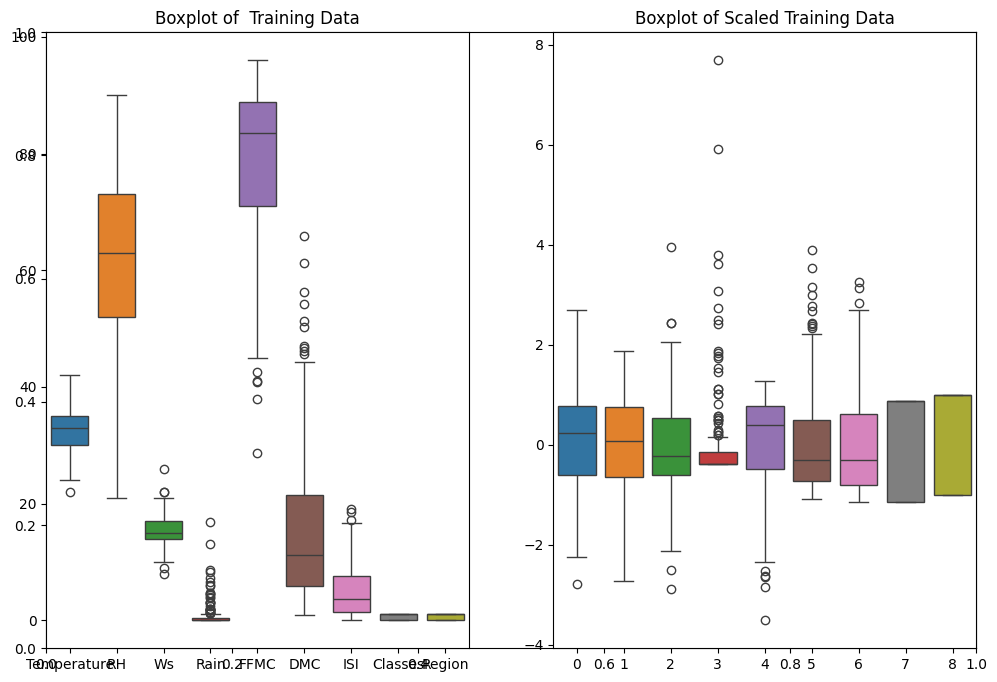

In [18]:
plt.subplots(figsize=(12, 8))
plt.subplot(1,2,1)
sns.boxplot(data=X_train)
plt.title('Boxplot of  Training Data')
plt.subplot(1,2,2)
sns.boxplot(data=X_train_scaled)    
plt.title('Boxplot of Scaled Training Data')
plt.show()

****Linear Regression****

Mean Squared Error: 0.5882990110708652
R^2 Score: 0.9805895859259883
Mean Absolute Error: 0.5049978694165659


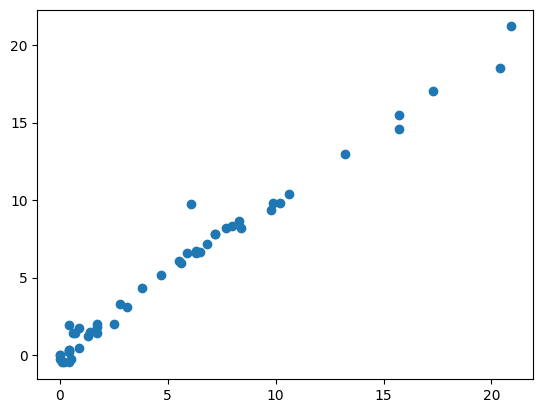

In [19]:
from sklearn.linear_model import LinearRegression   
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
y_pred = lr_model.predict(X_test_scaled)
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error   
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')
print(f'R^2 Score: {r2}')
print(f'Mean Absolute Error: {mae}')
plt.scatter(y_test, y_pred)


***Lasso Regression***

Lasso Mean Squared Error: 1.7260423250231411
Lasso R^2 Score: 0.9430507350726564
Lasso Mean Absolute Error: 1.0093958923873405


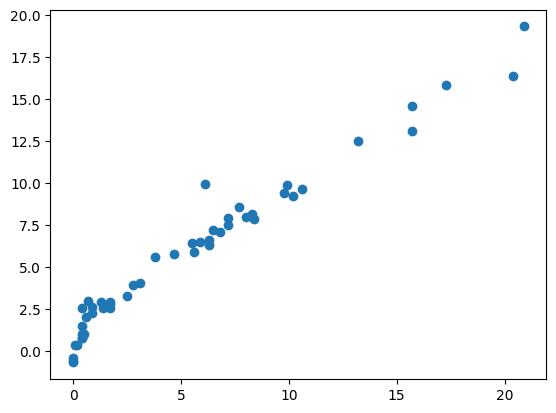

In [20]:
from sklearn.linear_model import Lasso
lasso_model = Lasso()
lasso_model.fit(X_train_scaled, y_train)
y_pred_lasso = lasso_model.predict(X_test_scaled)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
print(f'Lasso Mean Squared Error: {mse_lasso}')
print(f'Lasso R^2 Score: {r2_lasso}')
print(f'Lasso Mean Absolute Error: {mae_lasso}')
plt.scatter(y_test, y_pred_lasso)

LassoCV Mean Squared Error: 0.6675945416803813
LassoCV R^2 Score: 0.9779732988774219
LassoCV Mean Absolute Error: 0.5619043833707776


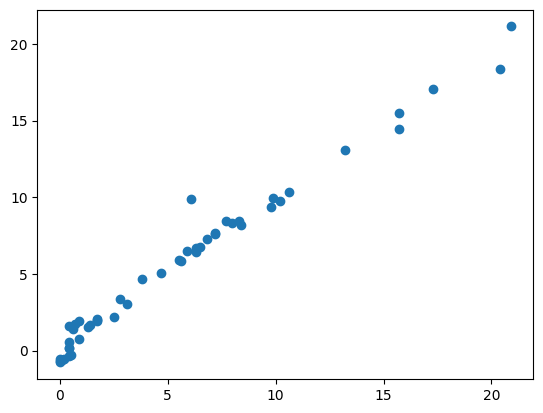

In [21]:
from sklearn.linear_model import LassoCV
lasso_cv_model = LassoCV(cv=5)
lasso_cv_model.fit(X_train_scaled, y_train)
y_pred_lasso_cv = lasso_cv_model.predict(X_test_scaled)
mse_lasso_cv = mean_squared_error(y_test, y_pred_lasso_cv)
r2_lasso_cv = r2_score(y_test, y_pred_lasso_cv)
mae_lasso_cv = mean_absolute_error(y_test, y_pred_lasso_cv)
print(f'LassoCV Mean Squared Error: {mse_lasso_cv}')
print(f'LassoCV R^2 Score: {r2_lasso_cv}')
print(f'LassoCV Mean Absolute Error: {mae_lasso_cv}')
plt.scatter(y_test, y_pred_lasso_cv)


In [22]:
lasso_cv_model.alphas_

array([7.1563667 , 6.67405153, 6.2242428 , 5.80474966, 5.41352896,
       5.04867523, 4.70841142, 4.39108025, 4.09513613, 3.81913766,
       3.56174057, 3.32169117, 3.09782031, 2.88903759, 2.69432612,
       2.51273756, 2.34338746, 2.18545099, 2.0381589 , 1.90079382,
       1.77268667, 1.65321353, 1.54179247, 1.43788081, 1.34097246,
       1.2505954 , 1.16630946, 1.08770411, 1.01439649, 0.94602956,
       0.88227033, 0.82280827, 0.76735374, 0.71563667, 0.66740515,
       0.62242428, 0.58047497, 0.5413529 , 0.50486752, 0.47084114,
       0.43910802, 0.40951361, 0.38191377, 0.35617406, 0.33216912,
       0.30978203, 0.28890376, 0.26943261, 0.25127376, 0.23433875,
       0.2185451 , 0.20381589, 0.19007938, 0.17726867, 0.16532135,
       0.15417925, 0.14378808, 0.13409725, 0.12505954, 0.11663095,
       0.10877041, 0.10143965, 0.09460296, 0.08822703, 0.08228083,
       0.07673537, 0.07156367, 0.06674052, 0.06224243, 0.0580475 ,
       0.05413529, 0.05048675, 0.04708411, 0.0439108 , 0.04095

In [23]:
lasso_cv_model.alpha_

np.float64(0.04708411417632532)

In [24]:
lasso_cv_model.mse_path_

array([[68.58934997, 64.28650232, 49.25415197, 79.11474083, 38.68688171],
       [63.2664675 , 58.77362304, 43.20292636, 77.07183352, 34.66910628],
       [56.87389457, 51.79652473, 37.15764773, 69.4806422 , 31.16497557],
       [51.2737596 , 45.69461734, 31.98560721, 62.80993539, 27.46286399],
       [45.36816855, 40.35928545, 27.56726322, 56.94442062, 23.75447628],
       [39.875005  , 35.69250404, 23.79907917, 50.31847875, 20.54655878],
       [35.0794232 , 31.60885664, 20.59132915, 44.35263414, 17.77349727],
       [30.89154006, 28.0342798 , 17.86626498, 39.14265375, 15.37720198],
       [27.23334321, 24.90389594, 15.55674604, 34.59116894, 13.30754905],
       [24.03652419, 22.16129069, 13.60451947, 30.61376519, 11.52101422],
       [21.24273995, 19.75730052, 11.95924131, 27.13693185,  9.97950732],
       [18.80004176, 17.64896267, 10.57738151, 24.09623192,  8.65087048],
       [16.66356323, 15.79916526,  9.42117661, 21.43679316,  7.50627555],
       [14.79422393, 14.17520895,  8.4

***Ridge Regression Model***

Ridge Mean Squared Error: 0.6029616070548639
Ridge R^2 Score: 0.9801058063273599
Ridge Mean Absolute Error: 0.5192048325844796


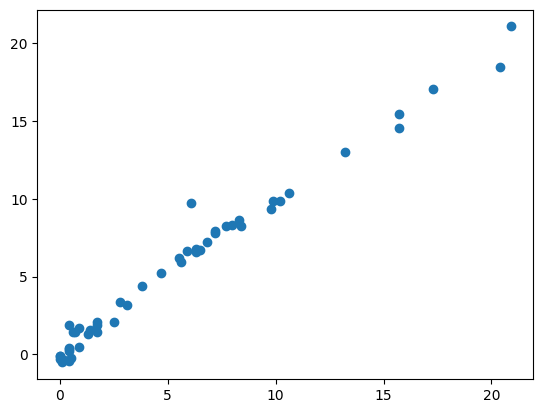

In [25]:
from sklearn.linear_model import Ridge
ridge_model = Ridge()
ridge_model.fit(X_train_scaled, y_train)
y_pred_ridge = ridge_model.predict(X_test_scaled)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
print(f'Ridge Mean Squared Error: {mse_ridge}')
print(f'Ridge R^2 Score: {r2_ridge}')
print(f'Ridge Mean Absolute Error: {mae_ridge}')
plt.scatter(y_test, y_pred_ridge)

RidgeCV Mean Squared Error: 0.841986797932755
RidgeCV R^2 Score: 0.9722193780965623
RidgeCV Mean Absolute Error: 0.6869262008277156


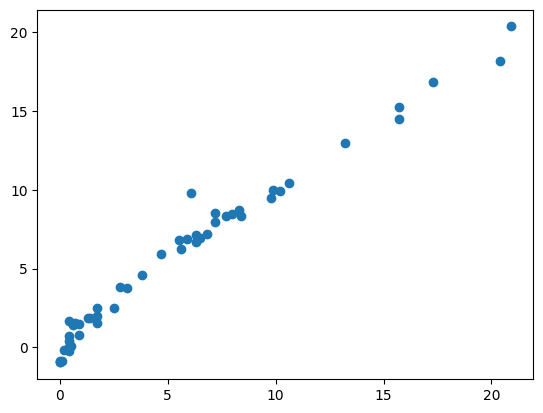

In [26]:
from sklearn.linear_model import RidgeCV
ridge_cv_model = RidgeCV(cv=5)
ridge_cv_model.fit(X_train_scaled, y_train)
y_pred_ridge_cv = ridge_cv_model.predict(X_test_scaled)
mse_ridge_cv = mean_squared_error(y_test, y_pred_ridge_cv)
r2_ridge_cv = r2_score(y_test, y_pred_ridge_cv)
mae_ridge_cv = mean_absolute_error(y_test, y_pred_ridge_cv)
print(f'RidgeCV Mean Squared Error: {mse_ridge_cv}')
print(f'RidgeCV R^2 Score: {r2_ridge_cv}')
print(f'RidgeCV Mean Absolute Error: {mae_ridge_cv}')

plt.scatter(y_test, y_pred_ridge_cv)


In [27]:
ridge_cv_model.alpha_

np.float64(10.0)

Elastic Net Mean Squared Error: 4.009921298441002
Elastic Net R^2 Score: 0.8676961352267807
Elastic Net Mean Absolute Error: 1.6834416340136709


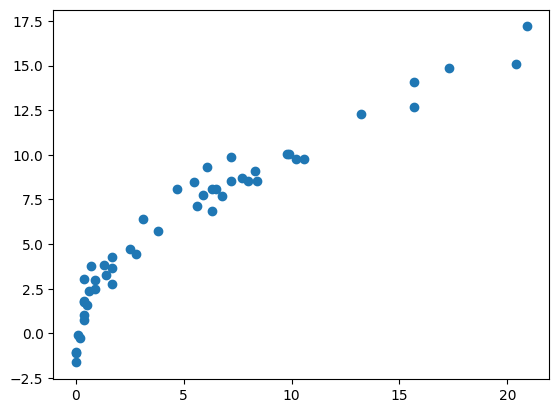

In [28]:
from sklearn.linear_model import ElasticNet
elastic_model = ElasticNet()

elastic_model.fit(X_train_scaled, y_train)
y_pred_elastic = elastic_model.predict(X_test_scaled)
mse_elastic = mean_squared_error(y_test, y_pred_elastic)
r2_elastic = r2_score(y_test, y_pred_elastic)
mae_elastic = mean_absolute_error(y_test, y_pred_elastic)
print(f'Elastic Net Mean Squared Error: {mse_elastic}')
print(f'Elastic Net R^2 Score: {r2_elastic}')
print(f'Elastic Net Mean Absolute Error: {mae_elastic}')
plt.scatter(y_test, y_pred_elastic)

Elastic Net CV Mean Squared Error: 0.6637102658943738
Elastic Net CV R^2 Score: 0.9781014571778188
Elastic Net CV Mean Absolute Error: 0.5710147088777221


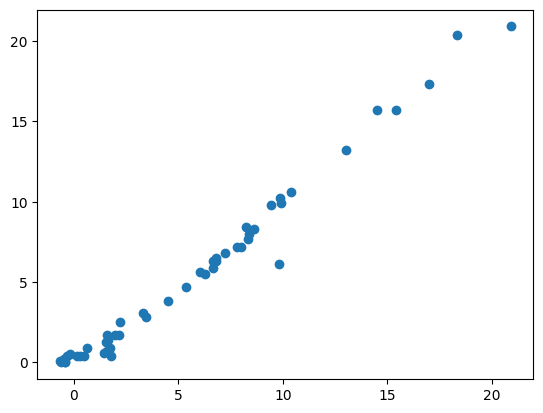

In [29]:
from sklearn.linear_model import ElasticNetCV
elastic_cv_model = ElasticNetCV(cv=5)
elastic_cv_model.fit(X_train_scaled, y_train)
y_pred_elastic_cv = elastic_cv_model.predict(X_test_scaled)
mse_elastic_cv = mean_squared_error(y_test, y_pred_elastic_cv)
r2_elastic_cv = r2_score(y_test, y_pred_elastic_cv)
mae_elastic_cv = mean_absolute_error(y_test, y_pred_elastic_cv)
print(f'Elastic Net CV Mean Squared Error: {mse_elastic_cv}')
print(f'Elastic Net CV R^2 Score: {r2_elastic_cv}')
print(f'Elastic Net CV Mean Absolute Error: {mae_elastic_cv}')
plt.scatter(y_pred_elastic_cv, y_test)

In [30]:
import pickle
pickle.dump(scaler, open('scaler.pkl', 'wb'))
pickle.dump(ridge_model, open('ridge.pkl', 'wb'))